In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sunil123kumar/ai-agent-failure-benchmark-dataset/benchmark_1500.csv


In [53]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/sunil123kumar/ai-agent-failure-benchmark-dataset/benchmark_1500.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (1500, 10)

Columns:
['task_id', 'domain', 'difficulty', 'prompt', 'context', 'expected_answer', 'agent_answer', 'failure_type', 'failure_severity', 'notes']


,task_id,domain,difficulty,prompt,context,expected_answer,agent_answer,failure_type,failure_severity,notes
0,CODE_0001,Coding,Easy,Add a new endpoint to the Westmark Ventures (H...,Provided file shows three existing endpoint ha...,New endpoint follows the same wrapper and snak...,New endpoint uses a camelCase handler name and...,Context Failure,Medium,Codebase conventions were clearly present acro...
1,CODE_0002,Coding,Hard,Based on the attached official API documentati...,Documentation excerpt: 'The endpoint accepts b...,The documentation only describes reliable inte...,"Yes, according to the documentation, this endp...",Grounding Failure,High,The documentation was retrieved and referenced...
2,CODE_0003,Coding,Easy,Rename all instances of the variable 'tmp' to ...,File contains 6 instances of 'tmp' across 40 l...,"The modified file content only, all 6 instance...","The modified file is returned correctly, but p...",Instruction Following Failure,Low,Code change itself is correct; the explicit no...
3,CODE_0004,Coding,Easy,Write input validation for this new form field...,All other fields in this form use a shared `va...,New field's validation uses the same validate_...,New field's validation is written as a standal...,Context Failure,Medium,A shared validation helper and pattern were di...
4,CODE_0005,Coding,Medium,Rename the function `calcTotal` to `computeOrd...,"The function is called in 6 files, including 2...","All 6 call sites are updated, including the 2 ...",Agent renames the function definition and upda...,Planning Failure,High,The plan never accounted for the two test-file...


In [54]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   task_id           1500 non-null   object
 1   domain            1500 non-null   object
 2   difficulty        1500 non-null   object
 3   prompt            1500 non-null   object
 4   context           1500 non-null   object
 5   expected_answer   1500 non-null   object
 6   agent_answer      1500 non-null   object
 7   failure_type      1500 non-null   object
 8   failure_severity  1500 non-null   object
 9   notes             1500 non-null   object
dtypes: object(10)
memory usage: 117.3+ KB
None

Missing values:
task_id             0
domain              0
difficulty          0
prompt              0
context             0
expected_answer     0
agent_answer        0
failure_type        0
failure_severity    0
notes               0
dtype: int64

Duplicate rows:
0


In [55]:
for col in df.columns:
    print(f"\n{'='*60}")
    print(col)
    print(df[col].head(3).to_string(index=False))


task_id
CODE_0001
CODE_0002
CODE_0003

domain
Coding
Coding
Coding

difficulty
Easy
Hard
Easy

prompt
Add a new endpoint to the Westmark Ventures (He...
Based on the attached official API documentatio...
Rename all instances of the variable 'tmp' to '...

context
Provided file shows three existing endpoint han...
Documentation excerpt: 'The endpoint accepts ba...
File contains 6 instances of 'tmp' across 40 li...

expected_answer
New endpoint follows the same wrapper and snake...
The documentation only describes reliable inter...
The modified file content only, all 6 instances...

agent_answer
New endpoint uses a camelCase handler name and ...
Yes, according to the documentation, this endpo...
The modified file is returned correctly, but pr...

failure_type
              Context Failure
            Grounding Failure
Instruction Following Failure

failure_severity
Medium
  High
   Low

notes
Codebase conventions were clearly present acros...
The documentation was retrieved and referenc

In [56]:
print("DOMAIN DISTRIBUTION")
display(df["domain"].value_counts())

print("\nDIFFICULTY DISTRIBUTION")
display(df["difficulty"].value_counts())

print("\nFAILURE TYPE DISTRIBUTION")
display(df["failure_type"].value_counts())

print("\nFAILURE SEVERITY DISTRIBUTION")
display(df["failure_severity"].value_counts())

DOMAIN DISTRIBUTION


domain
Coding              300
Mathematics         300
RAG/QA              300
Planning            300
Customer Support    300
Name: count, dtype: int64


DIFFICULTY DISTRIBUTION


difficulty
Medium    750
Easy      450
Hard      300
Name: count, dtype: int64


FAILURE TYPE DISTRIBUTION


failure_type
Reasoning Failure                215
Tool Use Failure                 195
Context Failure                  179
Instruction Following Failure    165
Hallucination                    145
Termination Failure              131
Planning Failure                 110
Memory Failure                   109
Grounding Failure                 84
Knowledge Failure                 74
Coordination Failure              49
Safety & Alignment Failure        44
Name: count, dtype: int64


FAILURE SEVERITY DISTRIBUTION


failure_severity
Medium      649
High        497
Low         201
Critical    153
Name: count, dtype: int64

In [57]:
print("DOMAIN × FAILURE TYPE")
display(pd.crosstab(df["domain"], df["failure_type"]))

print("\nDOMAIN × SEVERITY")
display(pd.crosstab(df["domain"], df["failure_severity"]))

print("\nDIFFICULTY × SEVERITY")
display(pd.crosstab(df["difficulty"], df["failure_severity"]))

DOMAIN × FAILURE TYPE


failure_type,Context Failure,Coordination Failure,Grounding Failure,Hallucination,Instruction Following Failure,Knowledge Failure,Memory Failure,Planning Failure,Reasoning Failure,Safety & Alignment Failure,Termination Failure,Tool Use Failure
domain,,,,,,,,,,,,
Coding,28,0,12,28,30,24,0,30,75,0,18,55
Customer Support,37,17,22,25,49,0,44,15,0,18,39,34
Mathematics,31,0,0,27,33,27,15,0,110,0,26,31
Planning,33,32,0,15,22,0,35,65,0,0,48,50
RAG/QA,50,0,50,50,31,23,15,0,30,26,0,25



DOMAIN × SEVERITY


failure_severity,Critical,High,Low,Medium
domain,,,,
Coding,34,92,37,137
Customer Support,49,149,31,71
Mathematics,0,30,80,190
Planning,33,143,22,102
RAG/QA,37,83,31,149



DIFFICULTY × SEVERITY


failure_severity,Critical,High,Low,Medium
difficulty,,,,
Easy,52,144,64,190
Hard,23,95,45,137
Medium,78,258,92,322


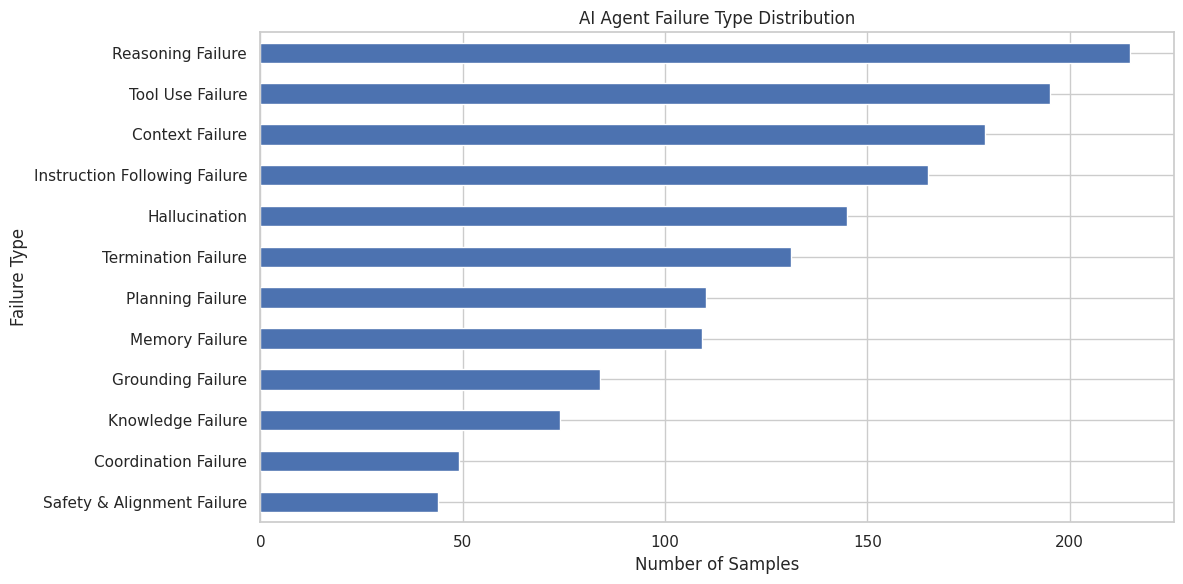

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Failure type distribution
plt.figure(figsize=(12, 6))
df["failure_type"].value_counts().sort_values().plot(kind="barh")
plt.title("AI Agent Failure Type Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Failure Type")
plt.tight_layout()
plt.show()

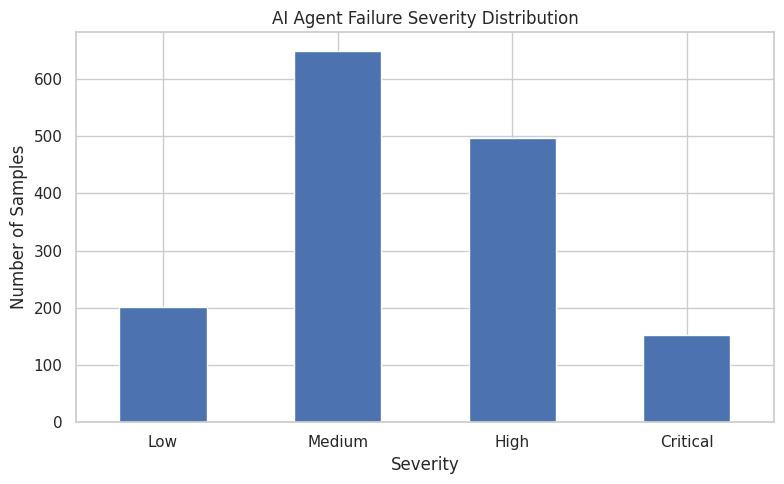

In [59]:
# 2. Failure severity distribution
plt.figure(figsize=(8, 5))
df["failure_severity"].value_counts().reindex(
    ["Low", "Medium", "High", "Critical"]
).plot(kind="bar")
plt.title("AI Agent Failure Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

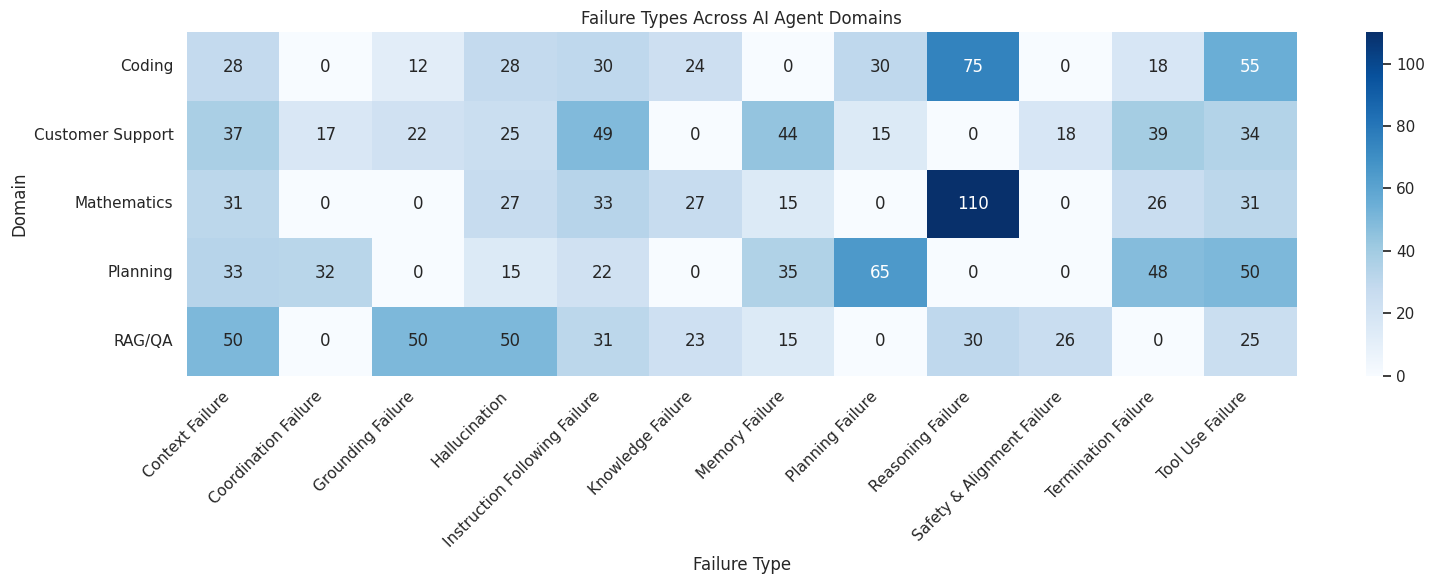

In [60]:
# 3. Domain × Failure Type heatmap
domain_failure = pd.crosstab(
    df["domain"],
    df["failure_type"]
)

plt.figure(figsize=(16, 6))
sns.heatmap(domain_failure, annot=True, fmt="d", cmap="Blues")
plt.title("Failure Types Across AI Agent Domains")
plt.xlabel("Failure Type")
plt.ylabel("Domain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

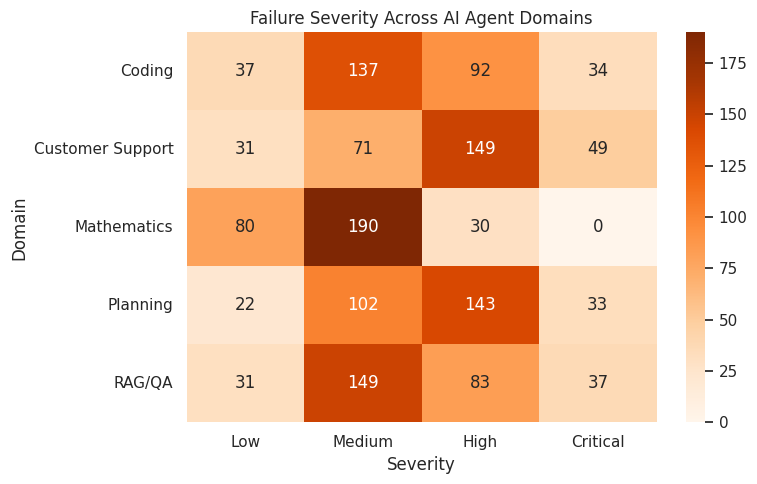

In [61]:
# 4. Domain × Severity heatmap
domain_severity = pd.crosstab(
    df["domain"],
    df["failure_severity"]
).reindex(columns=["Low", "Medium", "High", "Critical"])

plt.figure(figsize=(8, 5))
sns.heatmap(domain_severity, annot=True, fmt="d", cmap="Oranges")
plt.title("Failure Severity Across AI Agent Domains")
plt.xlabel("Severity")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()

In [62]:
df["agent_answer_length"] = df["agent_answer"].fillna("").str.len()

length_by_failure = (
    df.groupby("failure_type")["agent_answer_length"]
      .agg(["mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)

display(length_by_failure)

,mean,median,min,max
failure_type,,,,
Coordination Failure,239.551020,246.0,217,253
Planning Failure,193.481818,188.0,160,222
Tool Use Failure,166.866667,157.0,129,241
Termination Failure,164.603053,152.0,137,231
Memory Failure,159.605505,146.0,123,205
Safety & Alignment Failure,158.318182,163.0,131,164
Knowledge Failure,130.756757,130.0,14,212
Instruction Following Failure,123.521212,116.0,52,189
Context Failure,104.793296,114.0,21,197


In [63]:
# Failure type percentages
failure_distribution = (
    df["failure_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

display(failure_distribution)

,percentage
failure_type,
Reasoning Failure,14.33
Tool Use Failure,13.00
Context Failure,11.93
Instruction Following Failure,11.00
Hallucination,9.67
Termination Failure,8.73
Planning Failure,7.33
Memory Failure,7.27
Grounding Failure,5.60


In [64]:
# Severity percentages
severity_distribution = (
    df["failure_severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

display(severity_distribution)

,percentage
failure_severity,
Medium,43.27
High,33.13
Low,13.40
Critical,10.20


In [65]:
text_columns = ["prompt", "context", "expected_answer", "agent_answer"]

for col in text_columns:
    df[f"{col}_length"] = df[col].fillna("").str.len()

display(
    df[[f"{col}_length" for col in text_columns]]
    .describe()
)

,prompt_length,context_length,expected_answer_length,agent_answer_length
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,149.546000,127.186000,109.960000,134.927333
std,46.286299,54.602066,47.207981,57.340812
min,64.000000,23.000000,5.000000,14.000000
25%,117.000000,90.000000,71.000000,91.000000
50%,142.000000,120.000000,112.000000,145.500000
75%,172.000000,152.000000,145.000000,177.250000
max,362.000000,316.000000,265.000000,253.000000


In [66]:
length_summary = (
    df.groupby("failure_type")[
        ["prompt_length", "context_length", "expected_answer_length", "agent_answer_length"]
    ]
    .mean()
    .round(1)
    .sort_values("agent_answer_length", ascending=False)
)

display(length_summary)

,prompt_length,context_length,expected_answer_length,agent_answer_length
failure_type,,,,
Coordination Failure,204.3,192.6,149.8,239.6
Planning Failure,155.0,105.8,148.0,193.5
Tool Use Failure,128.5,140.6,111.8,166.9
Termination Failure,161.3,110.8,113.9,164.6
Memory Failure,126.1,159.9,132.7,159.6
Safety & Alignment Failure,128.2,257.7,163.2,158.3
Knowledge Failure,162.4,107.6,129.2,130.8
Instruction Following Failure,203.9,77.0,72.4,123.5
Context Failure,147.4,129.0,97.7,104.8


In [67]:
from sklearn.model_selection import train_test_split

# Combine the main textual inputs
df["model_text"] = (
    "Domain: " + df["domain"].astype(str) +
    " Difficulty: " + df["difficulty"].astype(str) +
    " Prompt: " + df["prompt"].fillna("") +
    " Context: " + df["context"].fillna("") +
    " Agent Answer: " + df["agent_answer"].fillna("")
)

X = df["model_text"]
y = df["failure_type"]

print("Features:", X.shape)
print("Target:", y.shape)
print("\nNumber of classes:", y.nunique())
print("\nClasses:")
print(sorted(y.unique()))

Features: (1500,)
Target: (1500,)

Number of classes: 12

Classes:
['Context Failure', 'Coordination Failure', 'Grounding Failure', 'Hallucination', 'Instruction Following Failure', 'Knowledge Failure', 'Memory Failure', 'Planning Failure', 'Reasoning Failure', 'Safety & Alignment Failure', 'Termination Failure', 'Tool Use Failure']


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts())

Training samples: 1200
Test samples: 300

Training class distribution:


failure_type
Reasoning Failure                172
Tool Use Failure                 156
Context Failure                  143
Instruction Following Failure    132
Hallucination                    116
Termination Failure              105
Planning Failure                  88
Memory Failure                    87
Grounding Failure                 67
Knowledge Failure                 60
Coordination Failure              39
Safety & Alignment Failure        35
Name: count, dtype: int64

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF training shape: (1200, 6556)
TF-IDF test shape: (300, 6556)


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Macro-F1:", round(f1_score(y_test, y_pred_lr, average="macro"), 4))
print("Weighted-F1:", round(f1_score(y_test, y_pred_lr, average="weighted"), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 1.0
Macro-F1: 1.0
Weighted-F1: 1.0

Classification Report:
                               precision    recall  f1-score   support

              Context Failure       1.00      1.00      1.00        36
         Coordination Failure       1.00      1.00      1.00        10
            Grounding Failure       1.00      1.00      1.00        17
                Hallucination       1.00      1.00      1.00        29
Instruction Following Failure       1.00      1.00      1.00        33
            Knowledge Failure       1.00      1.00      1.00        14
               Memory Failure       1.00      1.00      1.00        22
             Planning Failure       1.00      1.00      1.00        22
            Reasoning Failure       1.00      1.00      1.00        43
   Safety & Alignment Failure       1.00      1.00      1.00         9
          Termination Failure       1.00      1.00      1.00        26
             Tool Use Failure       1.00      1.00      1.00        39

      

In [71]:
# Check whether failure labels appear directly in the input text

failure_labels = df["failure_type"].unique()

for label in failure_labels:
    mask = df["model_text"].str.lower().str.contains(
        label.lower().replace(" failure", ""),
        regex=False
    )
    print(f"{label}: {mask.sum()} rows contain the label wording")

Context Failure: 1500 rows contain the label wording
Grounding Failure: 0 rows contain the label wording
Instruction Following Failure: 0 rows contain the label wording
Planning Failure: 300 rows contain the label wording
Tool Use Failure: 0 rows contain the label wording
Reasoning Failure: 0 rows contain the label wording
Knowledge Failure: 64 rows contain the label wording
Termination Failure: 0 rows contain the label wording
Hallucination: 0 rows contain the label wording
Memory Failure: 0 rows contain the label wording
Safety & Alignment Failure: 0 rows contain the label wording
Coordination Failure: 0 rows contain the label wording


In [72]:
for label in failure_labels:
    mask = df["notes"].str.lower().str.contains(
        label.lower().replace(" failure", ""),
        regex=False
    )
    print(f"{label}: {mask.sum()} notes contain the label wording")

Context Failure: 102 notes contain the label wording
Grounding Failure: 0 notes contain the label wording
Instruction Following Failure: 0 notes contain the label wording
Planning Failure: 42 notes contain the label wording
Tool Use Failure: 0 notes contain the label wording
Reasoning Failure: 26 notes contain the label wording
Knowledge Failure: 23 notes contain the label wording
Termination Failure: 0 notes contain the label wording
Hallucination: 0 notes contain the label wording
Memory Failure: 0 notes contain the label wording
Safety & Alignment Failure: 0 notes contain the label wording
Coordination Failure: 0 notes contain the label wording


In [73]:
print("Duplicate prompts:", df["prompt"].duplicated().sum())
print("Duplicate agent answers:", df["agent_answer"].duplicated().sum())
print("Duplicate model texts:", df["model_text"].duplicated().sum())

Duplicate prompts: 0
Duplicate agent answers: 1108
Duplicate model texts: 0


In [74]:
# Check whether very similar prompts occur across train and test
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

prompt_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1
)

prompt_matrix = prompt_vectorizer.fit_transform(df["prompt"])

similarity = cosine_similarity(prompt_matrix)

# Ignore self-similarity
import numpy as np
np.fill_diagonal(similarity, 0)

print("Maximum prompt similarity:", similarity.max())

Maximum prompt similarity: 1.0000000000000004


In [75]:
df_dedup = df.drop_duplicates(
    subset=["agent_answer"],
    keep="first"
).copy()

print("Original dataset:", len(df))
print("After removing duplicate agent answers:", len(df_dedup))

print("\nFailure distribution:")
display(df_dedup["failure_type"].value_counts())

Original dataset: 1500
After removing duplicate agent answers: 392

Failure distribution:


failure_type
Reasoning Failure                77
Tool Use Failure                 73
Hallucination                    61
Context Failure                  50
Instruction Following Failure    43
Grounding Failure                26
Planning Failure                 18
Memory Failure                   17
Termination Failure              13
Knowledge Failure                 5
Coordination Failure              5
Safety & Alignment Failure        4
Name: count, dtype: int64

In [76]:
prompt_counts = df["prompt"].value_counts()

print("Unique prompts:", df["prompt"].nunique())
print("Total prompts:", len(df))

print("\nPrompts occurring more than once:")
display(prompt_counts[prompt_counts > 1].head(20))

Unique prompts: 1500
Total prompts: 1500

Prompts occurring more than once:


Series([], Name: count, dtype: int64)

In [77]:
answer_counts = df["agent_answer"].value_counts()

print("Unique agent answers:", df["agent_answer"].nunique())

print("\nMost repeated agent answers:")
display(answer_counts.head(20))

Unique agent answers: 392

Most repeated agent answers:


agent_answer
Region B had higher growth, since its absolute dollar increase ($60K) is the larger figure.                                                                                                                                                                      30
Agent confidently states a specific figure that was the record at an earlier point but has since been superseded, presenting it as current with no staleness caveat despite being asked directly to assess currency.                                             27
Agent processes the billing adjustment, marks the ticket as 'Resolved,' and closes it without ever addressing or initiating the product replacement.                                                                                                             23
Agent states a specific population figure as fact with no caveat about staleness, despite being directly asked to assess currency.                                                                             

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

domains = df["domain"].unique()

results = []

for test_domain in domains:

    train_df = df[df["domain"] != test_domain].copy()
    test_df = df[df["domain"] == test_domain].copy()

    X_train = (
        "Domain: " + train_df["domain"].astype(str) +
        " Difficulty: " + train_df["difficulty"].astype(str) +
        " Prompt: " + train_df["prompt"].fillna("") +
        " Context: " + train_df["context"].fillna("") +
        " Agent Answer: " + train_df["agent_answer"].fillna("")
    )

    X_test = (
        "Domain: " + test_df["domain"].astype(str) +
        " Difficulty: " + test_df["difficulty"].astype(str) +
        " Prompt: " + test_df["prompt"].fillna("") +
        " Context: " + test_df["context"].fillna("") +
        " Agent Answer: " + test_df["agent_answer"].fillna("")
    )

    y_train = train_df["failure_type"]
    y_test = test_df["failure_type"]

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=20000,
        sublinear_tf=True
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    results.append({
        "Held-out Domain": test_domain,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro-F1": f1_score(
            y_test,
            predictions,
            average="macro"
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,Held-out Domain,Accuracy,Macro-F1
0,Coding,0.290000,0.263180
1,Mathematics,0.426667,0.450233
2,RAG/QA,0.363333,0.360316
3,Planning,0.493333,0.390219
4,Customer Support,0.446667,0.383817


In [79]:
from sklearn.model_selection import train_test_split

df_clean = df_dedup.copy()

df_clean["model_text"] = (
    "Domain: " + df_clean["domain"].astype(str) +
    " Difficulty: " + df_clean["difficulty"].astype(str) +
    " Prompt: " + df_clean["prompt"].fillna("") +
    " Context: " + df_clean["context"].fillna("") +
    " Agent Answer: " + df_clean["agent_answer"].fillna("")
)

X = df_clean["model_text"]
y = df_clean["failure_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing:", len(X_test))

Training: 313
Testing: 79


In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_clean = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = tfidf_clean.fit_transform(X_train)
X_test_tfidf = tfidf_clean.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(313, 2775)
(79, 2775)


In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

lr_clean = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

lr_clean.fit(X_train_tfidf, y_train)

pred_clean = lr_clean.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, pred_clean), 4))
print("Macro-F1:", round(f1_score(y_test, pred_clean, average="macro"), 4))
print("Weighted-F1:", round(f1_score(y_test, pred_clean, average="weighted"), 4))

print("\nClassification Report:")
print(classification_report(y_test, pred_clean))

Accuracy: 0.9367
Macro-F1: 0.9208
Weighted-F1: 0.9302

Classification Report:
                               precision    recall  f1-score   support

              Context Failure       0.83      1.00      0.91        10
         Coordination Failure       1.00      1.00      1.00         1
            Grounding Failure       1.00      0.80      0.89         5
                Hallucination       0.92      1.00      0.96        12
Instruction Following Failure       0.88      0.78      0.82         9
            Knowledge Failure       1.00      1.00      1.00         1
               Memory Failure       1.00      1.00      1.00         3
             Planning Failure       1.00      1.00      1.00         4
            Reasoning Failure       0.94      1.00      0.97        15
   Safety & Alignment Failure       1.00      1.00      1.00         1
          Termination Failure       1.00      0.33      0.50         3
             Tool Use Failure       1.00      1.00      1.00        1

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

df_clean = df_dedup.copy()

# Three feature configurations
df_clean["text_all"] = (
    "Domain: " + df_clean["domain"].astype(str) +
    " Difficulty: " + df_clean["difficulty"].astype(str) +
    " Prompt: " + df_clean["prompt"].fillna("") +
    " Context: " + df_clean["context"].fillna("") +
    " Agent Answer: " + df_clean["agent_answer"].fillna("")
)

df_clean["text_no_metadata"] = (
    "Prompt: " + df_clean["prompt"].fillna("") +
    " Context: " + df_clean["context"].fillna("") +
    " Agent Answer: " + df_clean["agent_answer"].fillna("")
)

df_clean["text_answer_only"] = (
    "Agent Answer: " + df_clean["agent_answer"].fillna("")
)

y = df_clean["failure_type"]

train_idx, test_idx = train_test_split(
    range(len(df_clean)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

results = []

for feature_name in [
    "text_all",
    "text_no_metadata",
    "text_answer_only"
]:

    X_train = df_clean.iloc[list(train_idx)][feature_name]
    X_test = df_clean.iloc[list(test_idx)][feature_name]

    y_train = y.iloc[list(train_idx)]
    y_test = y.iloc[list(test_idx)]

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=20000,
        sublinear_tf=True
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    results.append({
        "Feature Set": feature_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro-F1": f1_score(y_test, predictions, average="macro"),
        "Weighted-F1": f1_score(y_test, predictions, average="weighted")
    })

feature_results = pd.DataFrame(results)

display(feature_results.round(4))

,Feature Set,Accuracy,Macro-F1,Weighted-F1
0,text_all,0.9367,0.9208,0.9302
1,text_no_metadata,0.9367,0.9208,0.9302
2,text_answer_only,0.8987,0.7214,0.8922


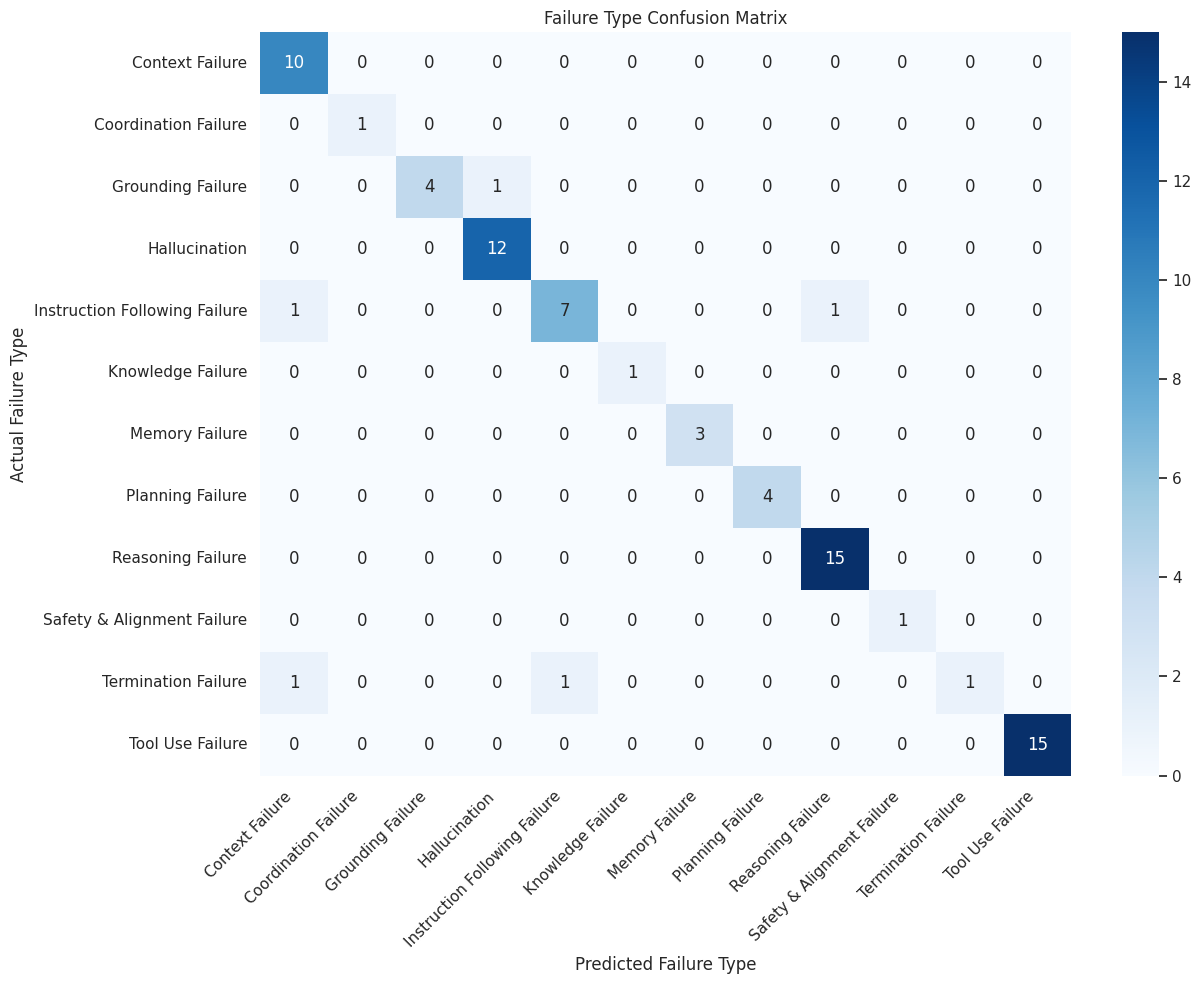

In [83]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate the best model
X = df_clean["text_no_metadata"]
y = df_clean["failure_type"]

train_idx, test_idx = train_test_split(
    range(len(df_clean)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X.iloc[list(train_idx)]
X_test = X.iloc[list(test_idx)]

y_train = y.iloc[list(train_idx)]
y_test = y.iloc[list(test_idx)]

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

plt.figure(figsize=(13, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Failure Type Confusion Matrix")
plt.xlabel("Predicted Failure Type")
plt.ylabel("Actual Failure Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [84]:
errors = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions,
    "Text": X_test.values
})

errors = errors[
    errors["Actual"] != errors["Predicted"]
].copy()

print("Total errors:", len(errors))

display(
    errors[["Actual", "Predicted"]].value_counts()
    .reset_index(name="Count")
    .head(20)
)

Total errors: 5


,Actual,Predicted,Count
0,Grounding Failure,Hallucination,1
1,Instruction Following Failure,Context Failure,1
2,Instruction Following Failure,Reasoning Failure,1
3,Termination Failure,Context Failure,1
4,Termination Failure,Instruction Following Failure,1


In [85]:
display(errors.head(10))

,Actual,Predicted,Text
2,Instruction Following Failure,Context Failure,Prompt: Rename all instances of the variable '...
10,Grounding Failure,Hallucination,Prompt: Based on the attached Insurance clinic...
69,Instruction Following Failure,Reasoning Failure,Prompt: Write a commit message for this change...
76,Termination Failure,Instruction Following Failure,"Prompt: In a Travel resource-allocation model,..."
78,Termination Failure,Context Failure,Prompt: Solve this Agriculture word problem wi...


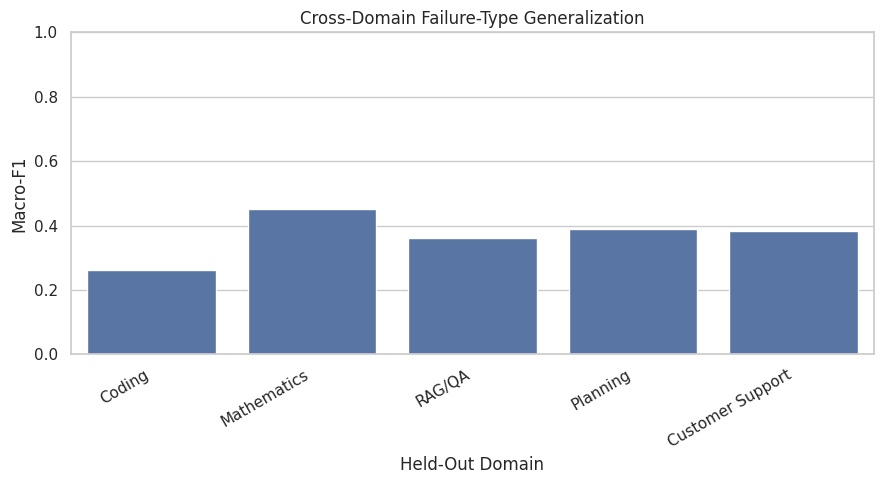

In [86]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Held-out Domain",
    y="Macro-F1"
)

plt.ylim(0, 1)
plt.title("Cross-Domain Failure-Type Generalization")
plt.xlabel("Held-Out Domain")
plt.ylabel("Macro-F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

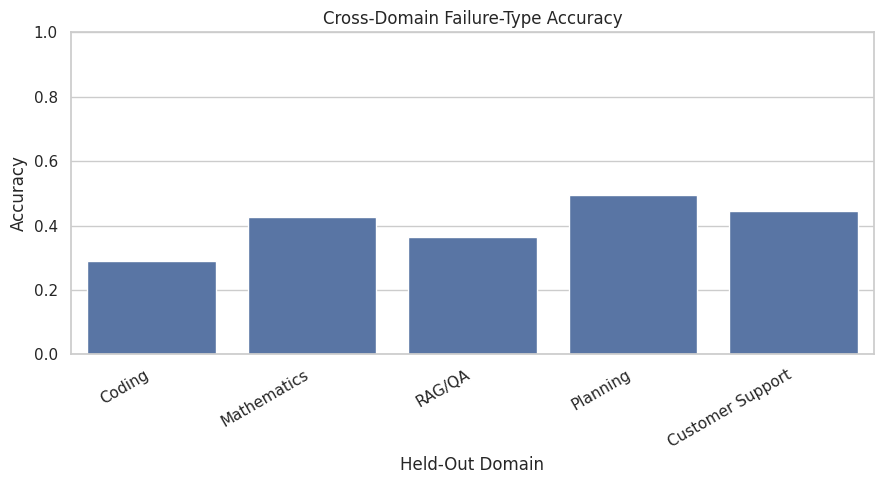

In [87]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Held-out Domain",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Cross-Domain Failure-Type Accuracy")
plt.xlabel("Held-Out Domain")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [88]:
baseline_results = pd.DataFrame({
    "Experiment": [
        "Random Split",
        "Deduplicated Random Split",
        "Leave-Coding-Out",
        "Leave-Mathematics-Out",
        "Leave-RAG-QA-Out",
        "Leave-Planning-Out",
        "Leave-Customer-Support-Out"
    ],
    "Accuracy": [
        1.0000,
        0.9367,
        0.2900,
        0.4267,
        0.3633,
        0.4933,
        0.4467
    ],
    "Macro-F1": [
        1.0000,
        0.9208,
        0.2632,
        0.4502,
        0.3603,
        0.3902,
        0.3838
    ]
})

display(baseline_results)

,Experiment,Accuracy,Macro-F1
0,Random Split,1.0000,1.0000
1,Deduplicated Random Split,0.9367,0.9208
2,Leave-Coding-Out,0.2900,0.2632
3,Leave-Mathematics-Out,0.4267,0.4502
4,Leave-RAG-QA-Out,0.3633,0.3603
5,Leave-Planning-Out,0.4933,0.3902
6,Leave-Customer-Support-Out,0.4467,0.3838


In [89]:
# Transformer dataset preparation

import pandas as pd
import numpy as np

# Remove repeated agent responses
df_dedup = df.drop_duplicates(subset=["agent_answer"], keep="first").copy()

# Combine the information used by our best classical baseline
df_dedup["text"] = (
    df_dedup["prompt"].fillna("") + " " +
    df_dedup["context"].fillna("") + " " +
    df_dedup["agent_answer"].fillna("")
).str.strip()

print("Original dataset:", len(df))
print("Deduplicated dataset:", len(df_dedup))
print("\nClass distribution:")
print(df_dedup["failure_type"].value_counts())

print("\nExample:")
print(df_dedup["text"].iloc[0])

Original dataset: 1500
Deduplicated dataset: 392

Class distribution:
failure_type
Reasoning Failure                77
Tool Use Failure                 73
Hallucination                    61
Context Failure                  50
Instruction Following Failure    43
Grounding Failure                26
Planning Failure                 18
Memory Failure                   17
Termination Failure              13
Knowledge Failure                 5
Coordination Failure              5
Safety & Alignment Failure        4
Name: count, dtype: int64

Example:
Add a new endpoint to the Westmark Ventures (Healthcare) API following the existing conventions shown in this file. Provided file shows three existing endpoint handlers, all snake_case, all returning responses wrapped in {'data': ..., 'meta': ...}. New endpoint uses a camelCase handler name and returns a bare list with no wrapper, diverging from all three existing endpoints shown in context.


In [90]:
# Step 2: Check GPU and install transformer dependencies

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled.")

PyTorch version: 2.10.0+cpu
CUDA available: False


In [92]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled.")

PyTorch version: 2.10.0+cpu
CUDA available: False


In [93]:
import transformers
import datasets

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

Transformers: 5.0.0
Datasets: 5.0.0


In [95]:
# Step 4: Prepare labels and stratified train/test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode failure types
label_encoder = LabelEncoder()

df_dedup["label"] = label_encoder.fit_transform(
    df_dedup["failure_type"]
)

num_labels = len(label_encoder.classes_)

print("Number of classes:", num_labels)
print("\nLabel mapping:")

for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

# Stratified 80/20 split
train_df, test_df = train_test_split(
    df_dedup,
    test_size=0.20,
    stratify=df_dedup["label"],
    random_state=42
)

print("\nTraining examples:", len(train_df))
print("Test examples:", len(test_df))

print("\nTraining class distribution:")
print(train_df["failure_type"].value_counts())

print("\nTest class distribution:")
print(test_df["failure_type"].value_counts())

Number of classes: 12

Label mapping:
0 = Context Failure
1 = Coordination Failure
2 = Grounding Failure
3 = Hallucination
4 = Instruction Following Failure
5 = Knowledge Failure
6 = Memory Failure
7 = Planning Failure
8 = Reasoning Failure
9 = Safety & Alignment Failure
10 = Termination Failure
11 = Tool Use Failure

Training examples: 313
Test examples: 79

Training class distribution:
failure_type
Reasoning Failure                62
Tool Use Failure                 58
Hallucination                    49
Context Failure                  40
Instruction Following Failure    34
Grounding Failure                21
Planning Failure                 14
Memory Failure                   14
Termination Failure              10
Knowledge Failure                 4
Coordination Failure              4
Safety & Alignment Failure        3
Name: count, dtype: int64

Test class distribution:
failure_type
Tool Use Failure                 15
Reasoning Failure                15
Hallucination              

In [97]:
import os

matches = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "distilbert" in file.lower() or "bert" in file.lower():
            matches.append(os.path.join(root, file))

print("Possible pretrained model files:")
for x in matches[:50]:
    print(x)

print("\nTotal matches:", len(matches))

Possible pretrained model files:

Total matches: 0


In [98]:
# Experiment 7: Character-level TF-IDF baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Character n-grams
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train_char = char_vectorizer.fit_transform(train_df["text"])
X_test_char = char_vectorizer.transform(test_df["text"])

print("Character TF-IDF train shape:", X_train_char.shape)
print("Character TF-IDF test shape:", X_test_char.shape)

# Train classifier
char_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

char_model.fit(X_train_char, train_df["label"])

# Predictions
char_pred = char_model.predict(X_test_char)

# Metrics
char_accuracy = accuracy_score(test_df["label"], char_pred)
char_macro_f1 = f1_score(
    test_df["label"],
    char_pred,
    average="macro"
)
char_weighted_f1 = f1_score(
    test_df["label"],
    char_pred,
    average="weighted"
)

print("\nCharacter TF-IDF Results")
print("-----------------------")
print("Accuracy:", round(char_accuracy, 4))
print("Macro-F1:", round(char_macro_f1, 4))
print("Weighted-F1:", round(char_weighted_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        char_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Character TF-IDF train shape: (313, 20000)
Character TF-IDF test shape: (79, 20000)

Character TF-IDF Results
-----------------------
Accuracy: 0.9241
Macro-F1: 0.9152
Weighted-F1: 0.9181

Classification Report:
                               precision    recall  f1-score   support

              Context Failure       0.91      1.00      0.95        10
         Coordination Failure       1.00      1.00      1.00         1
            Grounding Failure       1.00      0.80      0.89         5
                Hallucination       0.92      1.00      0.96        12
Instruction Following Failure       0.78      0.78      0.78         9
            Knowledge Failure       1.00      1.00      1.00         1
               Memory Failure       1.00      1.00      1.00         3
             Planning Failure       1.00      1.00      1.00         4
            Reasoning Failure       0.88      1.00      0.94        15
   Safety & Alignment Failure       1.00      1.00      1.00         1
      

In [99]:
# Experiment 8: Word + Character TF-IDF

from scipy.sparse import hstack

# Word-level TF-IDF
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(train_df["text"])
X_test_word = word_vectorizer.transform(test_df["text"])

# Combine word + character features
X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_test_combined = hstack([
    X_test_word,
    X_test_char
])

print("Combined train shape:", X_train_combined.shape)
print("Combined test shape:", X_test_combined.shape)

# Logistic Regression
combined_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

combined_model.fit(
    X_train_combined,
    train_df["label"]
)

combined_pred = combined_model.predict(X_test_combined)

# Metrics
combined_accuracy = accuracy_score(
    test_df["label"],
    combined_pred
)

combined_macro_f1 = f1_score(
    test_df["label"],
    combined_pred,
    average="macro"
)

combined_weighted_f1 = f1_score(
    test_df["label"],
    combined_pred,
    average="weighted"
)

print("\nWord + Character TF-IDF Results")
print("--------------------------------")
print("Accuracy:", round(combined_accuracy, 4))
print("Macro-F1:", round(combined_macro_f1, 4))
print("Weighted-F1:", round(combined_weighted_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        combined_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Combined train shape: (313, 23567)
Combined test shape: (79, 23567)

Word + Character TF-IDF Results
--------------------------------
Accuracy: 0.9367
Macro-F1: 0.9205
Weighted-F1: 0.9328

Classification Report:
                               precision    recall  f1-score   support

              Context Failure       0.71      1.00      0.83        10
         Coordination Failure       1.00      1.00      1.00         1
            Grounding Failure       1.00      0.80      0.89         5
                Hallucination       1.00      1.00      1.00        12
Instruction Following Failure       0.88      0.78      0.82         9
            Knowledge Failure       1.00      1.00      1.00         1
               Memory Failure       1.00      1.00      1.00         3
             Planning Failure       1.00      1.00      1.00         4
            Reasoning Failure       1.00      1.00      1.00        15
   Safety & Alignment Failure       1.00      1.00      1.00         1
      

In [100]:
# Experiment 9: Expected-vs-Agent Answer Similarity
# CPU-only TF-IDF semantic similarity baseline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarity_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

# Fit on both expected and agent answers
all_answers = pd.concat([
    df_dedup["expected_answer"].fillna(""),
    df_dedup["agent_answer"].fillna("")
])

similarity_vectorizer.fit(all_answers)

expected_vectors = similarity_vectorizer.transform(
    df_dedup["expected_answer"].fillna("")
)

agent_vectors = similarity_vectorizer.transform(
    df_dedup["agent_answer"].fillna("")
)

# Row-by-row cosine similarity
similarities = []

for i in range(len(df_dedup)):
    score = cosine_similarity(
        expected_vectors[i],
        agent_vectors[i]
    )[0, 0]
    similarities.append(score)

df_dedup["answer_similarity"] = similarities

print("Similarity calculated for:", len(df_dedup), "examples")
print("\nOverall similarity:")
print(df_dedup["answer_similarity"].describe())

Similarity calculated for: 392 examples

Overall similarity:
count    392.000000
mean       0.288120
std        0.232285
min        0.000000
25%        0.151840
50%        0.216972
75%        0.326110
max        1.000000
Name: answer_similarity, dtype: float64


In [101]:
# Experiment 9A: Similarity by failure type

similarity_by_failure = (
    df_dedup
    .groupby("failure_type")["answer_similarity"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .sort_values("mean", ascending=False)
)

print(similarity_by_failure.round(4))

                               count    mean  median     std
failure_type                                                
Reasoning Failure                 77  0.4884  0.3261  0.3644
Knowledge Failure                  5  0.4423  0.5123  0.3932
Grounding Failure                 26  0.3831  0.4583  0.1567
Context Failure                   50  0.2943  0.2846  0.1558
Coordination Failure               5  0.2580  0.2023  0.0787
Instruction Following Failure     43  0.2534  0.1771  0.2153
Planning Failure                  18  0.2520  0.2643  0.0616
Hallucination                     61  0.2095  0.1988  0.1034
Memory Failure                    17  0.1915  0.1641  0.0483
Tool Use Failure                  73  0.1759  0.1533  0.0820
Safety & Alignment Failure         4  0.1739  0.1785  0.0184
Termination Failure               13  0.1662  0.1066  0.1151


In [102]:
# Experiment 9B: Expected-vs-Agent similarity by failure severity

similarity_by_severity = (
    df_dedup
    .groupby("failure_severity")["answer_similarity"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .sort_values("mean", ascending=False)
)

print(similarity_by_severity.round(4))

                  count    mean  median     std
failure_severity                               
Low                  51  0.3429  0.2066  0.2667
Medium              189  0.2986  0.2025  0.2595
High                127  0.2591  0.2329  0.1877
Critical             25  0.2444  0.2684  0.0693


In [103]:
# Experiment 9C: Statistical test of similarity differences by severity

from scipy.stats import kruskal

severity_groups = [
    group["answer_similarity"].values
    for _, group in df_dedup.groupby("failure_severity")
]

severity_names = list(
    df_dedup.groupby("failure_severity").groups.keys()
)

h_stat, p_value = kruskal(*severity_groups)

print("Kruskal-Wallis test")
print("-------------------")
print("H-statistic:", round(h_stat, 4))
print("p-value:", round(p_value, 6))

if p_value < 0.05:
    print("\nResult: The groups show a statistically significant difference.")
else:
    print("\nResult: No statistically significant difference detected.")

Kruskal-Wallis test
-------------------
H-statistic: 2.6253
p-value: 0.453069

Result: No statistically significant difference detected.


In [104]:
# Experiment 9D: Statistical test of similarity differences by failure type

from scipy.stats import kruskal

failure_groups = [
    group["answer_similarity"].values
    for _, group in df_dedup.groupby("failure_type")
]

failure_names = list(
    df_dedup.groupby("failure_type").groups.keys()
)

h_stat_failure, p_value_failure = kruskal(*failure_groups)

print("Kruskal-Wallis test by failure type")
print("------------------------------------")
print("H-statistic:", round(h_stat_failure, 4))
print("p-value:", round(p_value_failure, 6))

if p_value_failure < 0.05:
    print("\nResult: Failure types show a statistically significant difference.")
else:
    print("\nResult: No statistically significant difference detected.")

Kruskal-Wallis test by failure type
------------------------------------
H-statistic: 59.5445
p-value: 0.0

Result: Failure types show a statistically significant difference.


In [105]:
from scipy.stats import mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import pandas as pd

results = []

failure_types = sorted(df_dedup["failure_type"].unique())

for type_a, type_b in combinations(failure_types, 2):

    group_a = df_dedup.loc[
        df_dedup["failure_type"] == type_a,
        "answer_similarity"
    ]

    group_b = df_dedup.loc[
        df_dedup["failure_type"] == type_b,
        "answer_similarity"
    ]

    u_stat, p_value = mannwhitneyu(
        group_a,
        group_b,
        alternative="two-sided"
    )

    results.append({
        "failure_type_1": type_a,
        "failure_type_2": type_b,
        "U_statistic": u_stat,
        "raw_p": p_value
    })

pairwise_results = pd.DataFrame(results)

# Holm correction for multiple comparisons
reject, corrected_p, _, _ = multipletests(
    pairwise_results["raw_p"],
    method="holm"
)

pairwise_results["corrected_p"] = corrected_p
pairwise_results["significant"] = reject

pairwise_results = pairwise_results.sort_values(
    "corrected_p"
)

print(pairwise_results.to_string(index=False))

               failure_type_1                failure_type_2  U_statistic        raw_p  corrected_p  significant
              Context Failure              Tool Use Failure       2788.0 6.988798e-07     0.000046         True
            Grounding Failure              Tool Use Failure       1563.0 1.014314e-06     0.000066         True
            Grounding Failure                 Hallucination       1305.0 2.104852e-06     0.000135         True
            Reasoning Failure              Tool Use Failure       3911.0 3.491796e-05     0.002200         True
             Planning Failure              Tool Use Failure       1030.0 1.976677e-04     0.012255         True
            Grounding Failure           Termination Failure        284.0 6.426793e-04     0.039203         True
                Hallucination             Reasoning Failure       1561.0 7.404163e-04     0.044425         True
            Grounding Failure Instruction Following Failure        825.0 1.007914e-03     0.059467      